In [1]:
from google.colab import drive
import zipfile
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define exact path based on your Google Drive screenshot
zip_path = '/content/drive/MyDrive/LLM_Google_collab/dataset_images.zip'

# THE FIX: Force it to extract INTO a specific folder, not the root
extract_path = '/content/dataset_images'

# 3. Extract locally for maximum A100 speed
print("Extracting images to local high-speed storage...")
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify the extraction path
if os.path.exists(extract_path):
    print(f"Extracted {len(os.listdir(extract_path))} files successfully to {extract_path}!")
else:
    print("WARNING: Double check your zip file structure!")

Mounted at /content/drive
Extracting images to local high-speed storage...
Extracted 3072 files successfully to /content/dataset_images!


In [2]:
import os
import pandas as pd
from datasets import Dataset, Features, Image, Value
from PIL import Image as PILImage

# 1. FIXED PATH: Read the CSV directly from your correct Google Drive folder
csv_path = '/content/drive/MyDrive/LLM_Google_collab/dataset_labels.csv'
df = pd.read_csv(csv_path)

# 2. Define the Prompt Template
SYSTEM_PROMPT = "You are an expert RF communications engineer. Identify the digital modulation scheme shown in the provided constellation diagram."

def format_vqa_data(row):
    # This now perfectly maps to the extracted folder on the Colab machine
    img_path = os.path.join('/content/dataset_images', row['filename'])
    modulation = row['modulation']

    messages = [
        {
            "role": "user",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}, {"type": "image"}]
        },
        {
            "role": "assistant",
            # THE SHIELD: Adding "Class: " protects the numerical tokens from merging
            "content": [{"type": "text", "text": f"Class: {modulation}"}]
        }
    ]
    return {"image": img_path, "messages": messages}

print("Formatting data into VQA Chat format...")

# 3. Apply the formatting to every row
formatted_data = [format_vqa_data(row) for _, row in df.iterrows()]

# 4. Convert to a Hugging Face Dataset object
features = Features({
    "image": Image(),
    "messages": [
        {
            "role": Value("string"),
            "content": [{"type": Value("string"), "text": Value("string")}]
        }
    ]
})

hf_dataset = Dataset.from_list(formatted_data, features=features)

# 5. Split the dataset (80/20 ratio)
hf_dataset = hf_dataset.train_test_split(test_size=0.20, seed=42)

print(f"Dataset successfully translated!")
print(f"Training samples: {len(hf_dataset['train'])}")
print(f"Validation samples: {len(hf_dataset['test'])}")

# Show an example
print("\n--- Example AI Input ---")
print(hf_dataset['train'][0]['messages'])

Formatting data into VQA Chat format...
Dataset successfully translated!
Training samples: 2457
Validation samples: 615

--- Example AI Input ---
[{'role': 'user', 'content': [{'type': 'text', 'text': 'You are an expert RF communications engineer. Identify the digital modulation scheme shown in the provided constellation diagram.'}, {'type': 'image', 'text': None}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Class: 16-APSK'}]}]


In [3]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from peft import LoraConfig, get_peft_model

print("Downloading and Loading SmolVLM (This may take a minute...)")

model_id = "HuggingFaceTB/SmolVLM-256M-Instruct"

# 1. Load the Processor
processor = AutoProcessor.from_pretrained(model_id)

# 2. Load the Base Model (UPGRADED for A100 Architecture)
model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16, # A100s natively accelerate bfloat16 math
)

# FIXED: Explicitly set device to CUDA for Nvidia GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Base model loaded to {device}! Now injecting LoRA adapters...")

# 3. Define the LoRA Configuration
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules="all-linear", # Vision bottleneck fixed!
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# 4. Inject the Adapters
peft_model = get_peft_model(model, lora_config)

peft_model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Base model loaded to cuda! Now injecting LoRA adapters...
trainable params: 7,744,512 || all params: 264,229,440 || trainable%: 2.9310


In [4]:
from transformers import TrainingArguments, Trainer

def collate_fn(examples):
    texts = [processor.apply_chat_template(example["messages"], tokenize=False) for example in examples]
    images = [example["image"] for example in examples]

    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    # Mask the user prompt
    for i, example in enumerate(examples):
        prompt_messages = [example["messages"][0]]
        prompt_text = processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
        prompt_tokens = processor.tokenizer(prompt_text, return_tensors="pt")["input_ids"][0]

        prompt_len = len(prompt_tokens)
        labels[i, :prompt_len] = -100

    labels[labels == processor.tokenizer.pad_token_id] = -100
    batch["labels"] = labels

    return batch

# 2. Define the Training Parameters (UPGRADED FOR A100 HIGH-RAM)
training_args = TrainingArguments(
    output_dir="./smolvlm_rf_model",
    per_device_train_batch_size=8,  # A100 can easily handle 8 images at once
    gradient_accumulation_steps=1,
    per_device_eval_batch_size=8,   # Faster evaluation

    dataloader_pin_memory=True,     # Turned back ON for Linux/Colab efficiency
    dataloader_num_workers=2,       # Use CPU cores to feed the GPU faster
    bf16=True,                      # Tell the Trainer to use A100 bfloat16 precision

    num_train_epochs=3,
    learning_rate=5e-5,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    remove_unused_columns=False,
    push_to_hub=False,
    gradient_checkpointing=True,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
)

# 3. Build the Trainer Engine
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=hf_dataset["train"],
    eval_dataset=hf_dataset["test"],
    data_collator=collate_fn,
)

print("Trainer Engine initialized. Commencing A100 VLM Fine-Tuning!")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer Engine initialized. Commencing A100 VLM Fine-Tuning!


Epoch,Training Loss,Validation Loss
1,0.003164,0.002820
2,0.001416,0.001663
3,0.001267,0.001326


TrainOutput(global_step=924, training_loss=1.196968452832601, metrics={'train_runtime': 2531.7152, 'train_samples_per_second': 2.911, 'train_steps_per_second': 0.365, 'total_flos': 1.2120690159195264e+16, 'train_loss': 1.196968452832601, 'epoch': 3.0})

Commencing VLM Final Exam on the Validation Set...


  0%|          | 0/615 [00:00<?, ?it/s]


Inference Complete! Generating LaTeX-Ready Artifacts...
✅ Saved: vlm_confusion_matrix.pdf


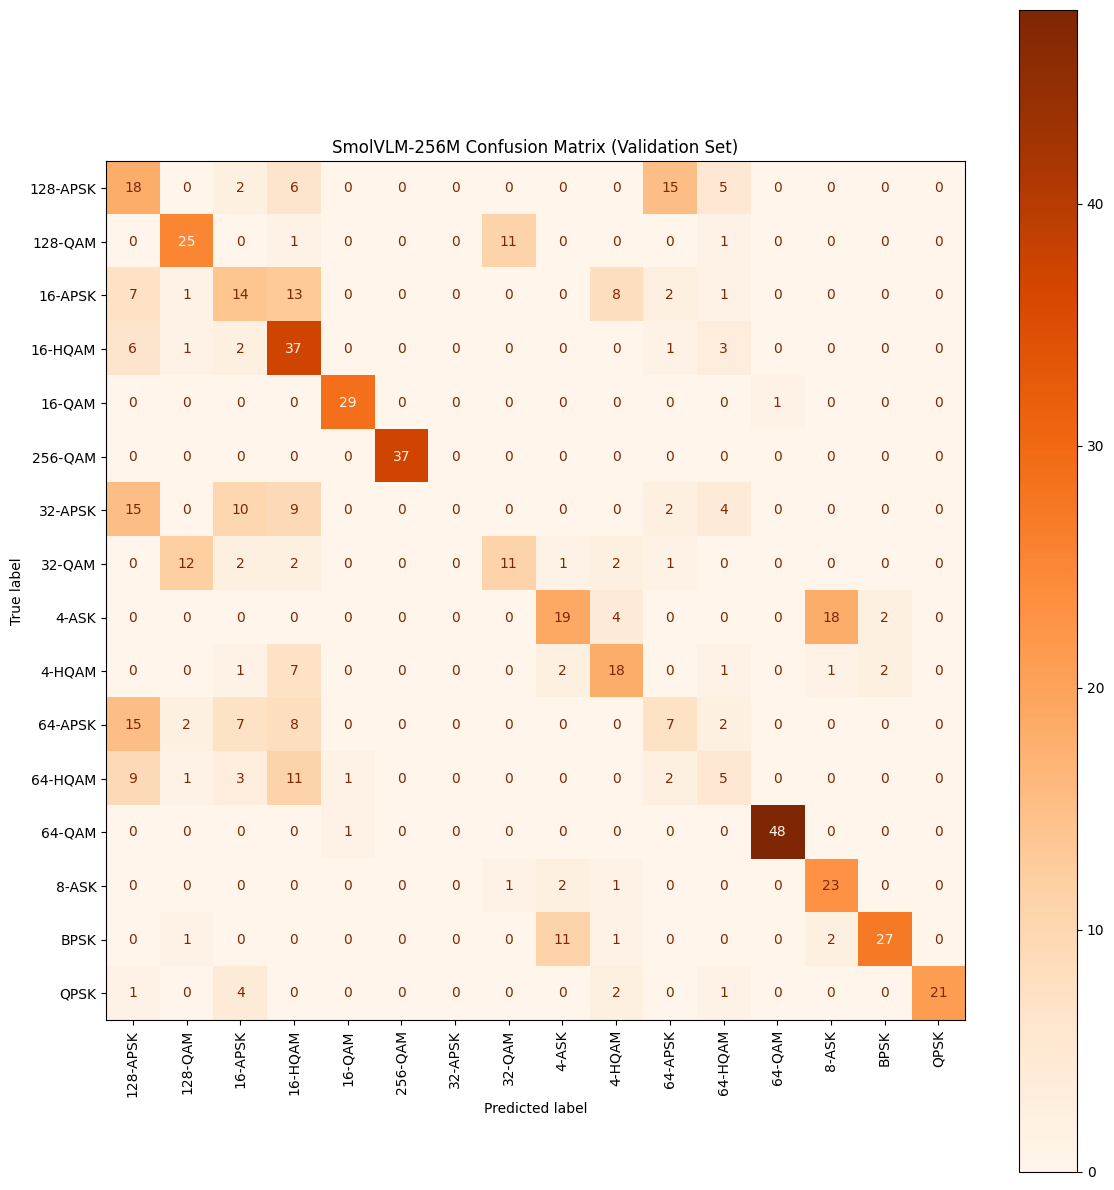

✅ Saved: vlm_classification_metrics.txt
✅ Saved: vlm_predictions.csv

--- SMOLVLM CLASSIFICATION METRICS ---
              precision    recall  f1-score   support

    128-APSK       0.25      0.39      0.31        46
     128-QAM       0.58      0.66      0.62        38
     16-APSK       0.31      0.30      0.31        46
     16-HQAM       0.39      0.74      0.51        50
      16-QAM       0.94      0.97      0.95        30
     256-QAM       1.00      1.00      1.00        37
     32-APSK       0.00      0.00      0.00        40
      32-QAM       0.48      0.35      0.41        31
       4-ASK       0.54      0.44      0.49        43
      4-HQAM       0.50      0.56      0.53        32
     64-APSK       0.23      0.17      0.20        41
     64-HQAM       0.22      0.16      0.18        32
      64-QAM       0.98      0.98      0.98        49
       8-ASK       0.52      0.85      0.65        27
        BPSK       0.87      0.61      0.72        44
        QPSK       1.00   

In [5]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tqdm.auto import tqdm
import pandas as pd

# 1. Prepare the Model for Testing
peft_model.eval()

modulations = sorted(df['modulation'].unique())

all_vlm_preds = []
all_vlm_labels = []

print("Commencing VLM Final Exam on the Validation Set...")

# 2. Iterate through the Test Set
for i in tqdm(range(len(hf_dataset["test"]))):
    sample = hf_dataset["test"][i]

    true_text = sample["messages"][1]["content"][0]["text"]

    prompt = processor.apply_chat_template([sample["messages"][0]], tokenize=False, add_generation_prompt=True)
    image = sample["image"]

    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = peft_model.generate(**inputs, max_new_tokens=10)

    # Slice the array to ONLY grab the new tokens
    input_len = inputs['input_ids'].shape[1]
    new_tokens = generated_ids[0][input_len:]

    # Decode and clean up the "Class: " shield
    generated_text = processor.decode(new_tokens, skip_special_tokens=True).strip()
    generated_text = generated_text.replace("Class: ", "").strip()

    # EXACT MATCHING ONLY
    pred_label = generated_text if generated_text in modulations else "Unknown"

    # Clean up True Label
    true_label_text = true_text.replace("Class: ", "").strip()
    true_label = true_label_text if true_label_text in modulations else "Unknown"

    all_vlm_labels.append(true_label)
    all_vlm_preds.append(pred_label)
print("\nInference Complete! Generating LaTeX-Ready Artifacts...")

# --- ARTIFACT 1: The VLM Confusion Matrix ---
cm_vlm = confusion_matrix(all_vlm_labels, all_vlm_preds, labels=modulations)
disp_vlm = ConfusionMatrixDisplay(confusion_matrix=cm_vlm, display_labels=modulations)

fig_cm_vlm, ax_cm_vlm = plt.subplots(figsize=(12, 12))
disp_vlm.plot(ax=ax_cm_vlm, cmap='Oranges', xticks_rotation='vertical')
plt.title('SmolVLM-256M Confusion Matrix (Validation Set)')
plt.tight_layout()

fig_cm_vlm.savefig('vlm_confusion_matrix.pdf', format='pdf', bbox_inches='tight')
print("✅ Saved: vlm_confusion_matrix.pdf")
plt.show()

# --- ARTIFACT 2: The Academic Classification Report ---
report_vlm = classification_report(all_vlm_labels, all_vlm_preds, labels=modulations, target_names=modulations, zero_division=0)
with open("vlm_classification_metrics.txt", "w") as f:
    f.write("--- SMOLVLM-256M CLASSIFICATION REPORT ---\n")
    f.write(report_vlm)
print("✅ Saved: vlm_classification_metrics.txt")

# --- ARTIFACT 3: The Raw CSV Predictions ---
results_df = pd.DataFrame({
    "True_Label": all_vlm_labels,
    "VLM_Prediction": all_vlm_preds
})
results_df.to_csv("vlm_predictions.csv", index=False)
print("✅ Saved: vlm_predictions.csv")

print("\n--- SMOLVLM CLASSIFICATION METRICS ---")
print(report_vlm)

In [6]:
import shutil
import os

print("Evacuating final results to Google Drive...")
drive_dest = '/content/drive/MyDrive/LLM_Google_collab/Final_VLM_Results'
os.makedirs(drive_dest, exist_ok=True)

try:
    shutil.copy("vlm_confusion_matrix.pdf", drive_dest)
    shutil.copy("vlm_classification_metrics.txt", drive_dest)
    shutil.copy("vlm_predictions.csv", drive_dest)
    print("✅ Diagrams and CSV safely secured in Drive!")
except FileNotFoundError as e:
    print(f"⚠️ Missing a file: {e}")

print("Copying LoRA model weights (this might take a minute...)")
try:
    shutil.copytree("./smolvlm_rf_model", os.path.join(drive_dest, "smolvlm_rf_model"), dirs_exist_ok=True)
    print("✅ Model weights safely secured in Drive!")
except Exception as e:
    print(f"⚠️ Issue copying model: {e}")

print(f"\n🚀 ALL CLEAR! Your files are in: {drive_dest}")

Evacuating final results to Google Drive...
✅ Diagrams and CSV safely secured in Drive!
Copying LoRA model weights (this might take a minute...)
✅ Model weights safely secured in Drive!

🚀 ALL CLEAR! Your files are in: /content/drive/MyDrive/LLM_Google_collab/Final_VLM_Results
